## imports

In [1]:
!pip install torch torchvision matplotlib seaborn scikit-learn pandas pillow tqdm opencv-python

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path
import time
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

#Set seed for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

#Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requ

## Paths & Class Names

In [2]:
# Cell 2: Define paths (Kaggle dataset with nested PlantVillage folder)
data_root = Path("/kaggle/input/datasets/mohitsingh1804/plantvillage") / "PlantVillage"
train_dir = data_root / "train"
val_dir   = data_root / "val"

if not train_dir.exists() or not val_dir.exists():
    raise FileNotFoundError(
        f"Train or val folder missing in {data_root}\n"
        f"Checked: {train_dir} and {val_dir}\n"
        "Please verify the dataset structure."
    )

# Get class names from train folder
class_names = sorted([d.name for d in train_dir.iterdir() if d.is_dir()])
num_classes = len(class_names)
print(f"Found {num_classes} classes:")
print(class_names[:38], "..." if num_classes > 10 else "")

Found 38 classes:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', '

## Preprocessing & Augmentation
We add an optional noise reduction step using GaussianBlur (can be toggled).

For training, strong augmentation helps generalisation.

For validation, only resize/crop/normalise.

In [3]:
#Transforms with optional noise reduction
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

 #Optional: Add GaussianBlur to reduce sensor noise (simulate real conditions)
use_noise_reduction = True   # set False if not needed

train_transform_list = [
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(30),
]

if use_noise_reduction:
    train_transform_list.insert(0, transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)))

train_transform_list.extend([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_transform = transforms.Compose(train_transform_list)

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

print("Train transforms:", train_transform)

Train transforms: Compose(
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 1.0))
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    RandomRotation(degrees=[-30.0, 30.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## Load Datasets & DataLoaders
We use torchvision.datasets.ImageFolder which automatically reads subfolders.

In [4]:
#Load train and val datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=val_transform)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

batch_size = 32   # adjust based on GPU memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=4, pin_memory=True)

Train samples: 43444
Val samples:   10861


## Model Definition (EfficientNet‑B3)

In [5]:
#Model with custom classifier
class PlantDiseaseClassifier(nn.Module):
    def __init__(self, num_classes=38, dropout=0.4):
        super().__init__()
        backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        in_features = backbone.classifier[1].in_features  # 1536
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(dropout * 0.75),
            nn.Linear(512, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = PlantDiseaseClassifier(num_classes=num_classes).to(device)
print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 168MB/s]


PlantDiseaseClassifier(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2

## Loss, Optimizer, Scheduler
We use class weights to handle possible imbalance.



In [6]:
# Class weights from train dataset
from sklearn.utils.class_weight import compute_class_weight

train_labels = [label for _, label in train_dataset.samples]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

## Training Loop with Early Stopping & CSV Logging
The trainer will:

Log train/val loss & accuracy after each epoch

Save best model based on validation accuracy

Stop if no improvement for patience epochs

Write history to training_log.csv

In [7]:
#Trainer with CSV logging
class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer,
                 scheduler, device, epochs=30, patience=5, output_dir="single_stage_model"):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.epochs = epochs
        self.patience = patience
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(exist_ok=True)

        self.best_val_acc = 0.0
        self.patience_counter = 0
        self.history = []  # list of dicts

    def train_one_epoch(self):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(self.train_loader, desc="Training"):
            images, labels = images.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

        return total_loss / total, correct / total

    @torch.no_grad()
    def validate(self):
        self.model.eval()
        total_loss, correct, total = 0, 0, 0
        for images, labels in tqdm(self.val_loader, desc="Validation"):
            images, labels = images.to(self.device), labels.to(self.device)
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += images.size(0)

        return total_loss / total, correct / total

    def fit(self):
        print(f"Starting training for {self.epochs} epochs...")
        for epoch in range(1, self.epochs + 1):
            start_time = time.time()
            train_loss, train_acc = self.train_one_epoch()
            val_loss, val_acc = self.validate()
            self.scheduler.step()
            epoch_time = time.time() - start_time

            #Record
            log_entry = {
                'epoch': epoch,
                'train_loss': round(train_loss, 4),
                'train_acc': round(train_acc, 4),
                'val_loss': round(val_loss, 4),
                'val_acc': round(val_acc, 4),
                'lr': self.optimizer.param_groups[0]['lr'],
                'time_sec': round(epoch_time, 2)
            }
            self.history.append(log_entry)

            print(f"Epoch {epoch}/{self.epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
                  f"LR: {log_entry['lr']:.2e} | Time: {epoch_time:.1f}s")

            #Save best model
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_acc': val_acc,
                }, self.output_dir / 'best_model.pth')
                print(f"  *** Best model saved (val_acc={val_acc:.4f}) ***")
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

        #Save CSV log
        df = pd.DataFrame(self.history)
        df.to_csv(self.output_dir / 'training_log.csv', index=False)
        print(f"Training log saved to {self.output_dir / 'training_log.csv'}")

        #Save JSON as well
        with open(self.output_dir / 'history.json', 'w') as f:
            json.dump(self.history, f, indent=2)

        print(f"Training finished. Best validation accuracy: {self.best_val_acc:.4f}")

#Instantiate and train
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=30,
    patience=5,
    output_dir="plant_disease_model"
)

trainer.fit()

Starting training for 30 epochs...


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch 1/30 | Train Loss: 2.0317 Acc: 0.7046 | Val Loss: 14.8812 Acc: 0.7393 | LR: 9.98e-06 | Time: 484.9s
  *** Best model saved (val_acc=0.7393) ***


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch 29/30 | Train Loss: 1.1983 Acc: 0.9756 | Val Loss: 1.7665 Acc: 0.9829 | LR: 1.02e-06 | Time: 485.5s


Training:   0%|          | 0/1358 [00:00<?, ?it/s]

Validation:   0%|          | 0/340 [00:00<?, ?it/s]

Epoch 30/30 | Train Loss: 1.1927 Acc: 0.9761 | Val Loss: 1.7567 Acc: 0.9851 | LR: 1.00e-06 | Time: 486.9s
  *** Best model saved (val_acc=0.9851) ***
Training log saved to plant_disease_model/training_log.csv
Training finished. Best validation accuracy: 0.9851


## Visualise Training Curves

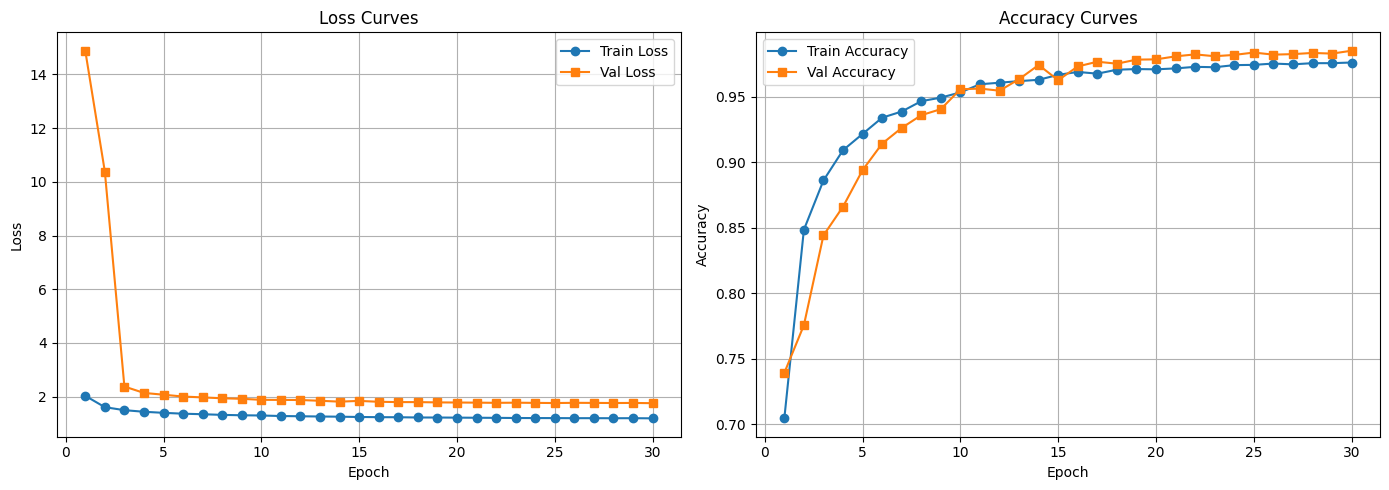

In [8]:
#Load CSV and plot
df_log = pd.read_csv("plant_disease_model/training_log.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_log['epoch'], df_log['train_loss'], label='Train Loss', marker='o')
ax1.plot(df_log['epoch'], df_log['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True)

ax2.plot(df_log['epoch'], df_log['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(df_log['epoch'], df_log['val_acc'], label='Val Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("plant_disease_model/training_curves.png", dpi=150)
plt.show()

## Final Evaluation on Validation Set

Loaded best model from epoch 30 with val_acc=0.9851


Evaluating on val set:   0%|          | 0/340 [00:00<?, ?it/s]


EVALUATION ON VALIDATION SET
Accuracy:                    0.9851
Macro Precision:             0.9789
Macro Recall:                0.9812
Macro F1-Score:              0.9798
Weighted Precision:          0.9853
Weighted Recall:             0.9851
Weighted F1-Score:           0.9851

Classification Report (per class):
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      1.00      0.98       126
                                 Apple___Black_rot       0.98      1.00      0.99       125
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      0.99      0.99       329
                               Blueberry___healthy       0.99      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_so

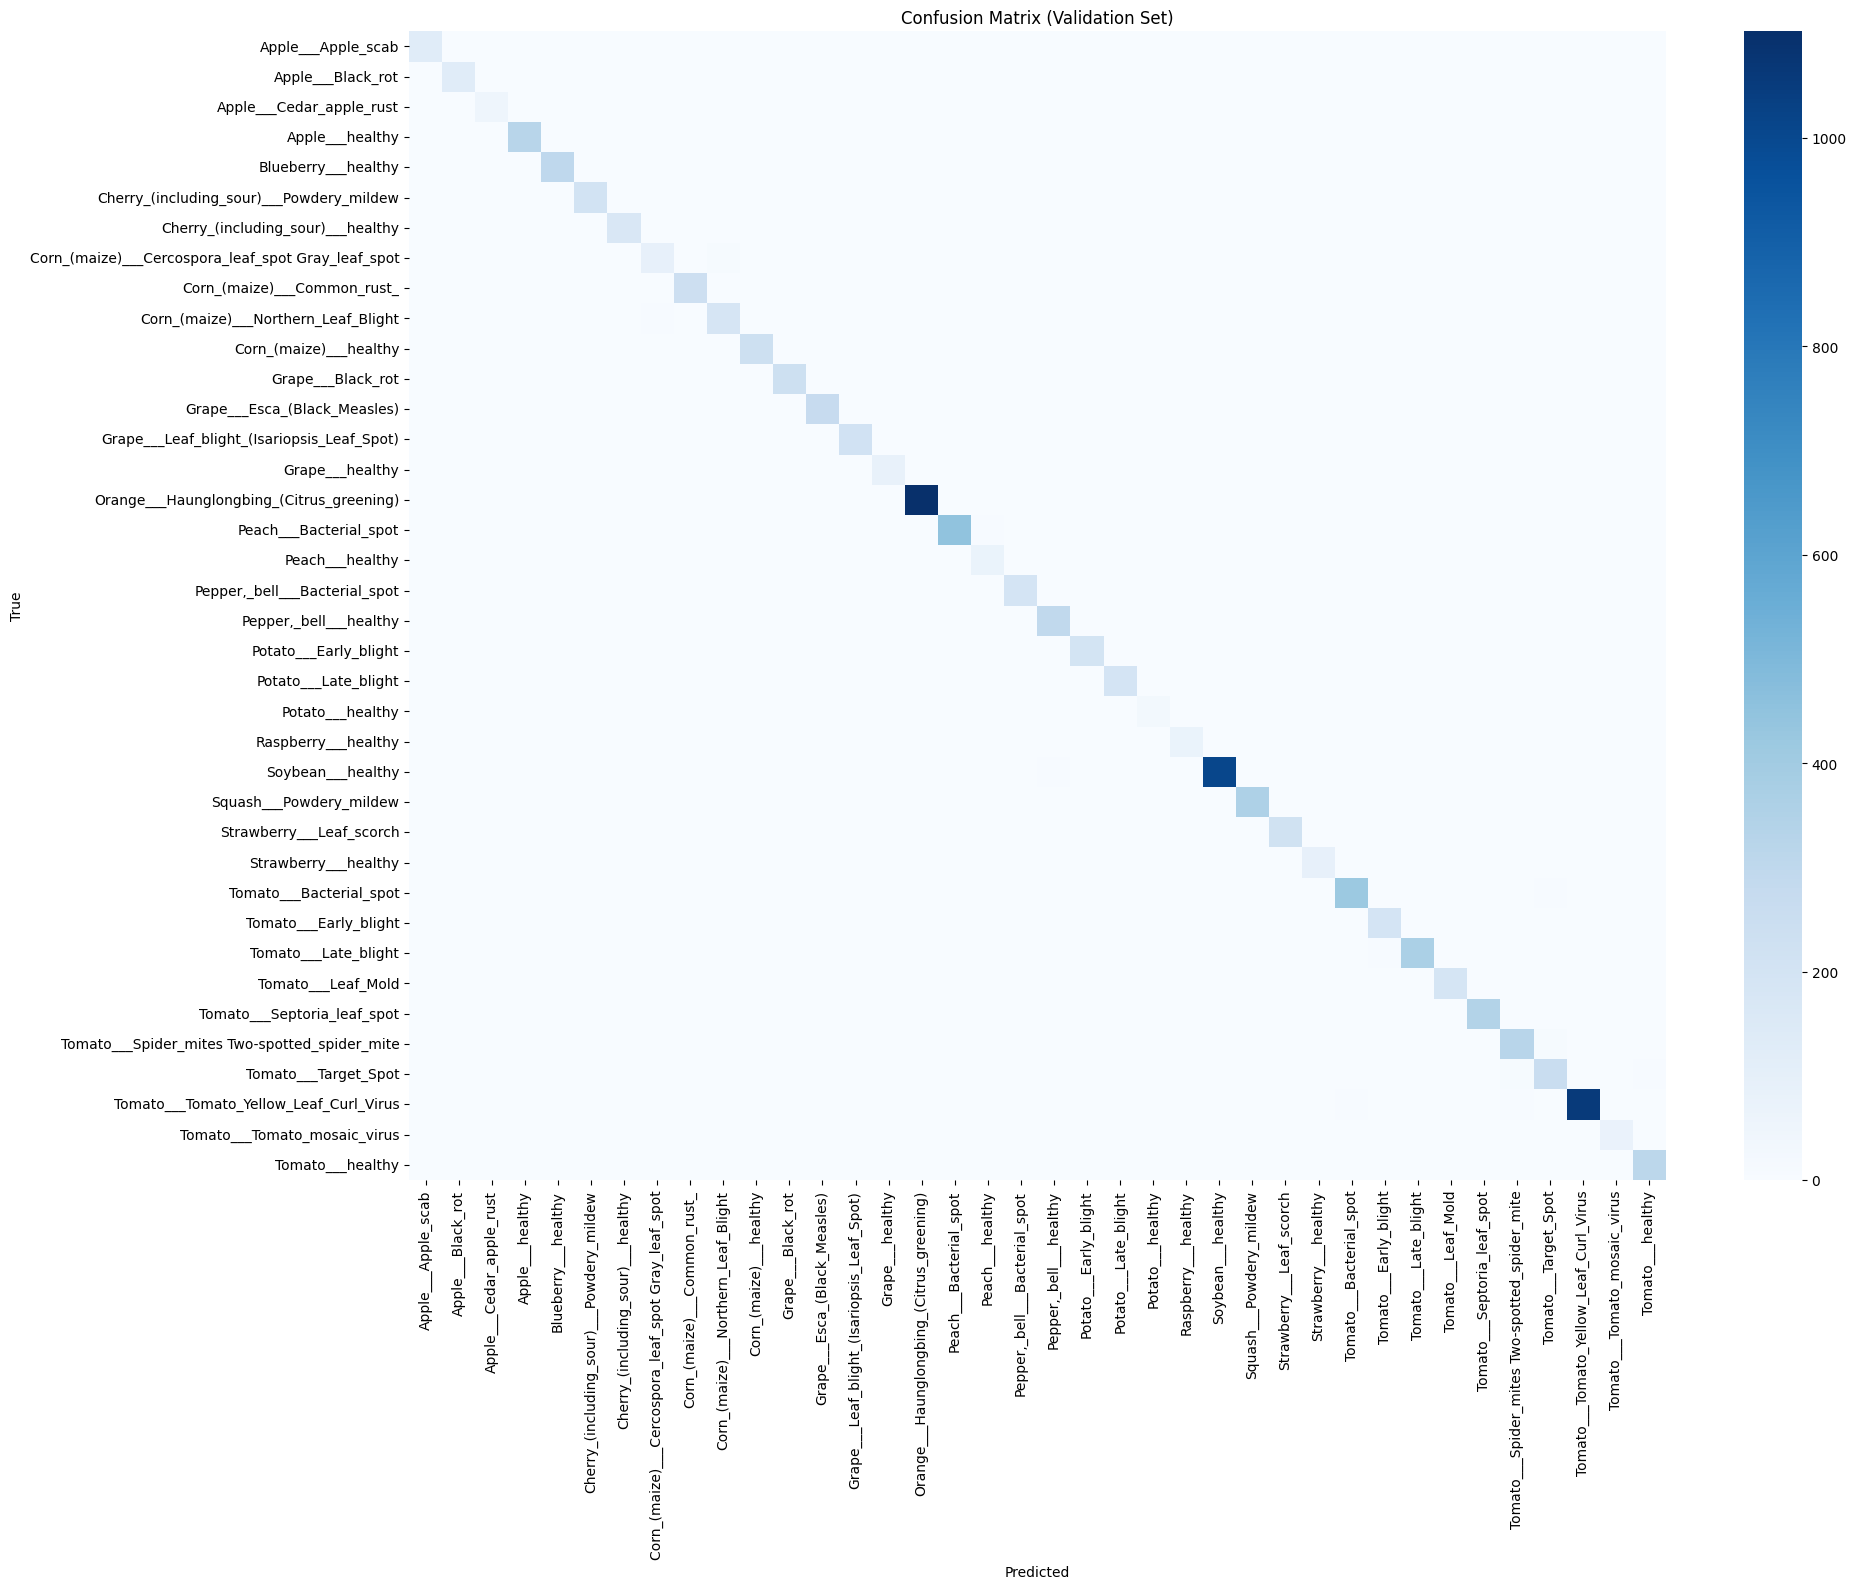

In [9]:
#Load best model and evaluate on validation set
checkpoint = torch.load("plant_disease_model/best_model.pth", map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} with val_acc={checkpoint['val_acc']:.4f}")

@torch.no_grad()
def evaluate(model, loader, class_names, device):
    model.eval()
    all_preds = []
    all_labels = []
    for images, labels in tqdm(loader, desc="Evaluating on val set"):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

    #Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted', zero_division=0)

    print("\n" + "="*60)
    print("EVALUATION ON VALIDATION SET")
    print("="*60)
    print(f"Accuracy:                    {accuracy:.4f}")
    print(f"Macro Precision:             {precision_macro:.4f}")
    print(f"Macro Recall:                {recall_macro:.4f}")
    print(f"Macro F1-Score:              {f1_macro:.4f}")
    print(f"Weighted Precision:          {precision_weighted:.4f}")
    print(f"Weighted Recall:             {recall_weighted:.4f}")
    print(f"Weighted F1-Score:           {f1_weighted:.4f}")
    print("="*60)

    #Detailed classification report
    print("\nClassification Report (per class):")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    #Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig("plant_disease_model/confusion_matrix.png", dpi=150)
    plt.show()

    return accuracy, precision_macro, recall_macro, f1_macro, cm

val_acc, val_prec_macro, val_rec_macro, val_f1_macro, cm = evaluate(
    model, val_loader, class_names, device
)

## Save Metrics to CSV & JSON

In [10]:
#Save evaluation metrics
metrics = {
    "accuracy": val_acc,
    "macro_precision": val_prec_macro,
    "macro_recall": val_rec_macro,
    "macro_f1": val_f1_macro,
    "num_classes": num_classes,
    "best_val_epoch": checkpoint['epoch']
}

with open("plant_disease_model/eval_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

#Also save confusion matrix as CSV
np.savetxt("plant_disease_model/confusion_matrix.csv", cm, delimiter=",", fmt="%d",
           header=",".join(class_names), comments="")

print("All results saved in 'plant_disease_model/' folder.")

All results saved in 'plant_disease_model/' folder.
